In [2]:
%%capture
# Install dependencies

!pip uninstall -y torch torchtext torchvision torchaudio numpy scanpy

!pip install "numpy<2" -q
!pip install torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install --no-deps git+https://github.com/bowang-lab/scGPT.git -q
!pip install "scanpy==1.10.4" wandb -q
!pip install "numpy<2" --force-reinstall --no-deps -q
!pip install --force-reinstall --no-deps torchtext==0.17.2 -q
!pip install scikit-misc -q

print("Restart session")

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(f"Scanpy  {sc.__version__}")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  {DEVICE}")

/usr/local/lib/python3.12/dist-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.12/dist-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Scanpy  1.10.4
PyTorch 2.2.2+cu121 | CUDA: True
Device  cuda


In [4]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR   = Path("/content/drive/MyDrive/CompGenProject/data")
EMBED_FILE = DATA_DIR / "PDAC_ADJ_embeddings.h5ad"

CELL_TYPE_KEY = "scGPT_target_label"
RANDOM_STATE  = 42
TEST_SIZE     = 0.2      # for within-condition split

# MLP hyperparameters
MLP_EPOCHS    = 100
MLP_LR        = 1e-3
MLP_DROPOUT   = 0.3
MLP_PATIENCE  = 10       # early stopping patience
BATCH_SIZE    = 256

Path("confusion_matrices").mkdir(exist_ok=True)

print(f"Input : {EMBED_FILE}  (exists: {EMBED_FILE.exists()})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input : /content/drive/MyDrive/CompGenProject/data/PDAC_ADJ_embeddings.h5ad  (exists: True)


In [5]:
print("\n-- Loading embeddings -----------------------------------------------")
adata = sc.read_h5ad(EMBED_FILE)
print(f"  Shape      : {adata.shape}")
print(f"  obsm keys  : {list(adata.obsm.keys())}")
print(f"  Conditions : {adata.obs['condition'].value_counts().to_dict()}")

# Encode cell type labels
le = LabelEncoder()
y_all = le.fit_transform(adata.obs[CELL_TYPE_KEY].values)
classes = le.classes_
n_classes = len(classes)
print(f"  Classes    : {n_classes}  {list(classes)}")

# Only keep cell types present in BOTH conditions (needed for cross-condition)
ct_pdac = set(adata[adata.obs["condition"] == "PDAC"].obs[CELL_TYPE_KEY].unique())
ct_adj  = set(adata[adata.obs["condition"] == "ADJ"].obs[CELL_TYPE_KEY].unique())
shared_cts = ct_pdac & ct_adj
print(f"\n  Cell types in both conditions : {len(shared_cts)}")
print(f"  ADJ-only  (excluded from cross-condition): {ct_adj - ct_pdac}")
print(f"  PDAC-only (excluded from cross-condition): {ct_pdac - ct_adj}")

# Masks
mask_adj  = (adata.obs["condition"] == "ADJ").values
mask_pdac = (adata.obs["condition"] == "PDAC").values
mask_shared = adata.obs[CELL_TYPE_KEY].isin(shared_cts).values

REPS = {
    "scGPT":   adata.obsm["X_scgpt"].astype(np.float32),
    "PCA-50":  adata.obsm["X_pca50"].astype(np.float32),
    "Raw-HVG": adata.obsm["X_raw_hvg"].astype(np.float32),
}


-- Loading embeddings -----------------------------------------------
  Shape      : (71074, 3000)
  obsm keys  : ['X_pca', 'X_pca50', 'X_raw_hvg', 'X_scgpt', 'X_umap']
  Conditions : {'PDAC': 38074, 'ADJ': 33000}
  Classes    : 14  ['Acinar', 'B-Cells', 'Ductal', 'Endocrine', 'Endothelial', 'Fibroblasts', 'Macrophages', 'Mast', 'NK', 'Neutrophils', 'Plasma', 'Schwann', 'Stellate', 'T-Cells']

  Cell types in both conditions : 9
  ADJ-only  (excluded from cross-condition): {'NK', 'Acinar', 'Endocrine'}
  PDAC-only (excluded from cross-condition): {'Plasma', 'Schwann'}


In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_classes, dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp(X_train, y_train, X_val, y_val, input_dim, n_classes,
              hidden_dims=[256, 128],
              epochs=60, lr=1e-3, dropout=0.3, patience=10,
              batch_size=256, device=DEVICE):

    model = MLP(input_dim, hidden_dims, n_classes, dropout).to(device)  # ← fixed
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=False
    )
    criterion = nn.CrossEntropyLoss()

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

    best_val_loss = float("inf")
    best_state    = None
    patience_ctr  = 0

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"      Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model


def predict_mlp(model, X, device=DEVICE):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32).to(device))
        return logits.argmax(dim=1).cpu().numpy()

In [7]:
def evaluate_split(X_train, y_train, X_test, y_test,
                   rep_name, experiment, classes, n_classes):
    """
    Trains LR, KNN, MLP on X_train/y_train and evaluates on X_test/y_test.
    Returns a list of result dicts.
    """
    # Scale features (fit on train only to avoid leakage)
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    results = []

    # -- Logistic Regression ------------------------------------------
    print(f"    LR...", end=" ")
    lr = LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs",
        multi_class="multinomial", n_jobs=-1, random_state=RANDOM_STATE,
    )
    lr.fit(X_tr_sc, y_train)
    y_pred_lr = lr.predict(X_te_sc)
    f1_lr  = f1_score(y_test, y_pred_lr, average="macro", zero_division=0)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f"macro-F1={f1_lr:.3f}")

    results.append({
        "representation": rep_name,
        "experiment":     experiment,
        "model":          "LR",
        "macro_f1":       f1_lr,
        "accuracy":       acc_lr,
        "y_pred":         y_pred_lr,
    })

    # -- KNN ----------------------------------------------------------
    print(f"    KNN...", end=" ")
    knn = KNeighborsClassifier(n_neighbors=10, metric="euclidean", n_jobs=-1)
    knn.fit(X_tr_sc, y_train)
    y_pred_knn = knn.predict(X_te_sc)
    f1_knn  = f1_score(y_test, y_pred_knn, average="macro", zero_division=0)
    acc_knn = accuracy_score(y_test, y_pred_knn)
    print(f"macro-F1={f1_knn:.3f}")

    results.append({
        "representation": rep_name,
        "experiment":     experiment,
        "model":          "KNN",
        "macro_f1":       f1_knn,
        "accuracy":       acc_knn,
        "y_pred":         y_pred_knn,
    })

    # -- MLP ----------------------------------------------------------
    print(f"    MLP...", end=" ")
    input_dim = X_tr_sc.shape[1]
    # Use a small val split from training data for early stopping
    X_tr2, X_val, y_tr2, y_val = train_test_split(
        X_tr_sc, y_train, test_size=0.1,
        stratify=y_train, random_state=RANDOM_STATE,
    )
    mlp = train_mlp(
        X_tr2, y_tr2, X_val, y_val,
        hidden_dims = [256, 128],
        input_dim=input_dim, n_classes=n_classes,
        epochs=MLP_EPOCHS, lr=MLP_LR, dropout=MLP_DROPOUT,
        patience=MLP_PATIENCE, batch_size=BATCH_SIZE,
    )
    y_pred_mlp = predict_mlp(mlp, X_te_sc)
    f1_mlp  = f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)
    acc_mlp = accuracy_score(y_test, y_pred_mlp)
    print(f"macro-F1={f1_mlp:.3f}")

    results.append({
        "representation": rep_name,
        "experiment":     experiment,
        "model":          "MLP",
        "macro_f1":       f1_mlp,
        "accuracy":       acc_mlp,
        "y_pred":         y_pred_mlp,
    })

    return results, y_test

In [8]:
print("\n-- Experiment A: Within-condition (train/test = 80/20 mixed) --------")

within_results = []

for rep_name, X_all in REPS.items():
    print(f"\n  [{rep_name}]")

    # Stratified split across all cells (both conditions mixed)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all,
        test_size=TEST_SIZE,
        stratify=y_all,
        random_state=RANDOM_STATE,
    )
    print(f"    Train: {X_tr.shape}  Test: {X_te.shape}")

    res, _ = evaluate_split(
        X_tr, y_tr, X_te, y_te,
        rep_name=rep_name,
        experiment="within_condition",
        classes=classes,
        n_classes=n_classes,
    )
    within_results.extend(res)

within_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in within_results
])
within_df.to_csv("within_condition_results.csv", index=False)
print("\n  Saved -> within_condition_results.csv")
print(within_df.pivot_table(
    index="model", columns="representation", values="macro_f1"
).round(3).to_string())



-- Experiment A: Within-condition (train/test = 80/20 mixed) --------

  [scGPT]
    Train: (56859, 512)  Test: (14215, 512)
    LR... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


macro-F1=0.950
    KNN... macro-F1=0.941
    MLP... 

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


      Early stop at epoch 54
macro-F1=0.953

  [PCA-50]
    Train: (56859, 50)  Test: (14215, 50)
    LR... 

...

      Early stop at epoch 50
macro-F1=0.949

  [Raw-HVG]
    Train: (56859, 3000)  Test: (14215, 3000)
    LR... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


macro-F1=0.934
    KNN... macro-F1=0.631
    MLP... 

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


      Early stop at epoch 12
macro-F1=0.910

  Saved -> within_condition_results.csv
representation  PCA-50  Raw-HVG  scGPT
model                                 
KNN              0.923    0.631  0.941
LR               0.924    0.934  0.950
MLP              0.949    0.910  0.953


In [9]:
print("\n-- Experiment B: Cross-condition (train=ADJ, test=PDAC) -------------")
print("  Using only cell types present in both conditions")

cross_results = []

# Restrict to shared cell types only
adata_shared = adata[mask_shared]
y_shared     = le.transform(adata_shared.obs[CELL_TYPE_KEY].values)
mask_adj_sh  = (adata_shared.obs["condition"] == "ADJ").values
mask_pdac_sh = (adata_shared.obs["condition"] == "PDAC").values

# Re-encode labels using only shared classes for cleaner confusion matrices
le_shared = LabelEncoder()
y_shared  = le_shared.fit_transform(adata_shared.obs[CELL_TYPE_KEY].values)
classes_shared = le_shared.classes_
n_shared = len(classes_shared)
print(f"  Shared classes ({n_shared}): {list(classes_shared)}")

for rep_name, X_all in REPS.items():
    print(f"\n  [{rep_name}]")

    # Align X to shared cells
    shared_idx = np.where(mask_shared)[0]
    X_shared   = X_all[shared_idx]

    X_tr = X_shared[mask_adj_sh]
    y_tr = y_shared[mask_adj_sh]
    X_te = X_shared[mask_pdac_sh]
    y_te = y_shared[mask_pdac_sh]

    print(f"    Train (ADJ) : {X_tr.shape}")
    print(f"    Test  (PDAC): {X_te.shape}")

    res, y_te_out = evaluate_split(
        X_tr, y_tr, X_te, y_te,
        rep_name=rep_name,
        experiment="cross_condition",
        classes=classes_shared,
        n_classes=n_shared,
    )

    # Save confusion matrix for each model
    for r in res:
        cm = confusion_matrix(y_te_out, r["y_pred"])
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_shared,
            yticklabels=classes_shared,
            ax=ax,
        )
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"{rep_name} | {r['model']} | Cross-condition\n"
                     f"macro-F1={r['macro_f1']:.3f}")
        plt.tight_layout()
        fname = f"confusion_matrices/{rep_name}_{r['model']}_cross.png"
        plt.savefig(fname, dpi=120, bbox_inches="tight")
        plt.close()

    cross_results.extend(res)

cross_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in cross_results
])
cross_df.to_csv("cross_condition_results.csv", index=False)
print("\n  Saved -> cross_condition_results.csv")
print(cross_df.pivot_table(
    index="model", columns="representation", values="macro_f1"
).round(3).to_string())


-- Experiment B: Cross-condition (train=ADJ, test=PDAC) -------------
  Using only cell types present in both conditions
  Shared classes (9): ['B-Cells', 'Ductal', 'Endothelial', 'Fibroblasts', 'Macrophages', 'Mast', 'Neutrophils', 'Stellate', 'T-Cells']

  [scGPT]
    Train (ADJ) : (23873, 512)
    Test  (PDAC): (37179, 512)
    LR... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


macro-F1=0.964
    KNN... macro-F1=0.912
    MLP... 

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


      Early stop at epoch 32
macro-F1=0.963

  [PCA-50]
    Train (ADJ) : (23873, 50)
    Test  (PDAC): (37179, 50)
    LR... 

...

      Early stop at epoch 35
macro-F1=0.944

  [Raw-HVG]
    Train (ADJ) : (23873, 3000)
    Test  (PDAC): (37179, 3000)
    LR... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


macro-F1=0.952
    KNN... macro-F1=0.569
    MLP... 

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


      Early stop at epoch 17
macro-F1=0.945

  Saved -> cross_condition_results.csv
representation  PCA-50  Raw-HVG  scGPT
model                                 
KNN              0.877    0.569  0.912
LR               0.915    0.952  0.964
MLP              0.944    0.945  0.963



-- Plotting F1 heatmaps ---------------------------------------------


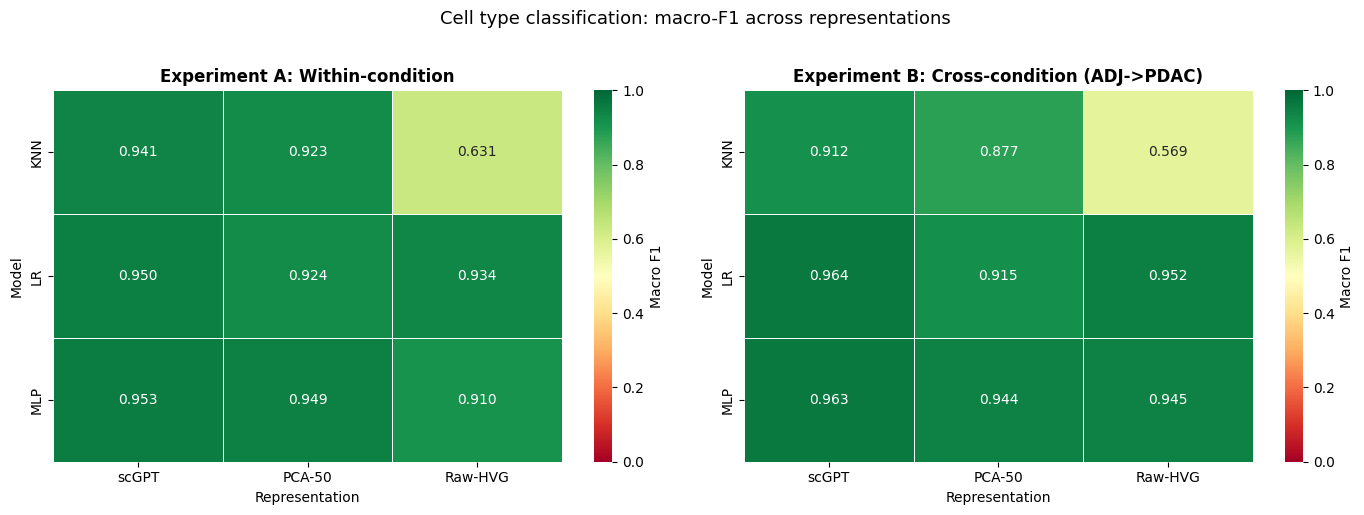

  Saved -> f1_heatmaps.png


In [10]:
print("\n-- Plotting F1 heatmaps ---------------------------------------------")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(
    axes,
    [within_df, cross_df],
    ["Experiment A: Within-condition", "Experiment B: Cross-condition (ADJ->PDAC)"],
):
    pivot = df.pivot_table(
        index="model",
        columns="representation",
        values="macro_f1",
    )[["scGPT", "PCA-50", "Raw-HVG"]]

    sns.heatmap(
        pivot, ax=ax,
        cmap="RdYlGn", vmin=0, vmax=1,
        annot=True, fmt=".3f",
        linewidths=0.5,
        cbar_kws={"label": "Macro F1"},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Representation"); ax.set_ylabel("Model")

plt.suptitle("Cell type classification: macro-F1 across representations",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("f1_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> f1_heatmaps.png")


-- Plotting F1 degradation (within -> cross) ------------------------

  F1 degradation (within -> cross condition):
model representation  within_f1  cross_f1  f1_drop  pct_drop
  KNN         PCA-50      0.923     0.877    0.046     4.935
  KNN        Raw-HVG      0.631     0.569    0.062     9.788
  KNN          scGPT      0.941     0.912    0.029     3.054
   LR         PCA-50      0.924     0.915    0.009     0.992
   LR        Raw-HVG      0.934     0.952   -0.017    -1.870
   LR          scGPT      0.950     0.964   -0.013    -1.395
  MLP         PCA-50      0.949     0.944    0.005     0.520
  MLP        Raw-HVG      0.910     0.945   -0.035    -3.869
  MLP          scGPT      0.953     0.963   -0.009    -0.991


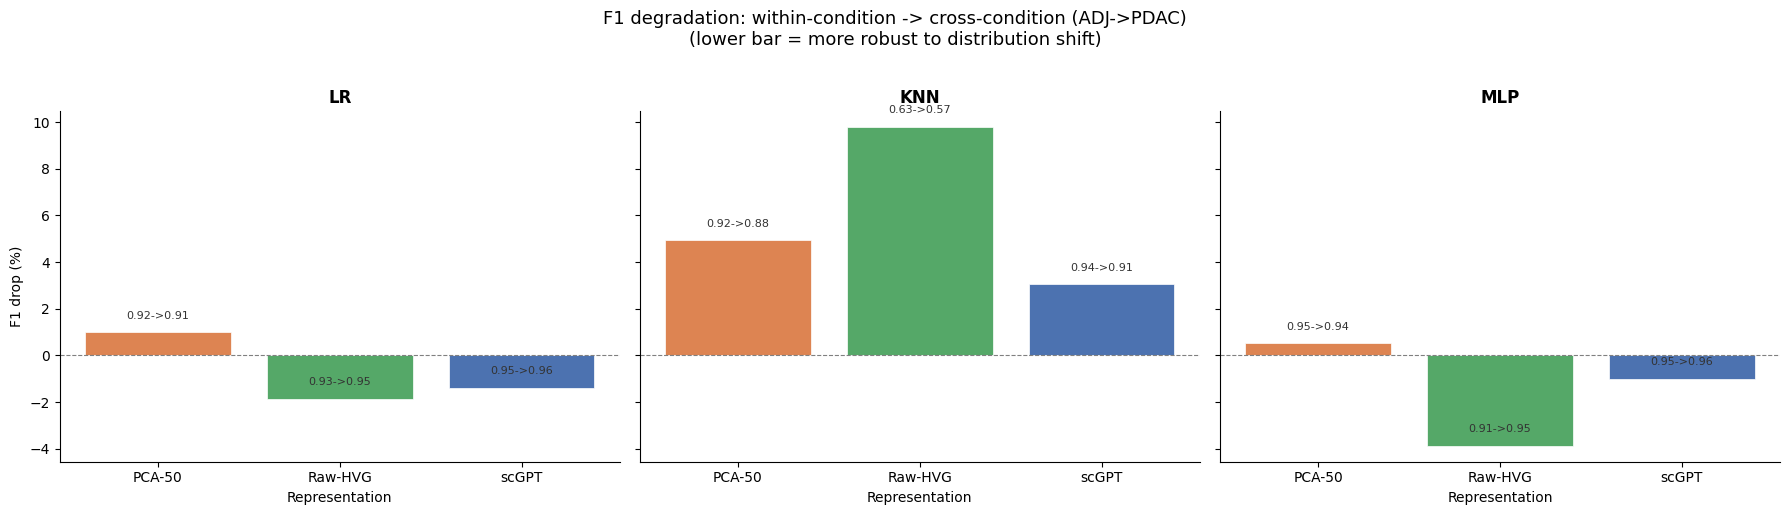

  Saved -> cross_condition_degradation.png


In [11]:
print("\n-- Plotting F1 degradation (within -> cross) ------------------------")

# Merge within and cross results
within_piv = within_df.pivot_table(
    index="model", columns="representation", values="macro_f1"
).reset_index().melt(id_vars="model", var_name="representation",
                     value_name="within_f1")

cross_piv = cross_df.pivot_table(
    index="model", columns="representation", values="macro_f1"
).reset_index().melt(id_vars="model", var_name="representation",
                     value_name="cross_f1")

deg_df = within_piv.merge(cross_piv, on=["model", "representation"])
deg_df["f1_drop"] = deg_df["within_f1"] - deg_df["cross_f1"]
deg_df["pct_drop"] = deg_df["f1_drop"] / deg_df["within_f1"] * 100

print("\n  F1 degradation (within -> cross condition):")
print(deg_df[["model", "representation", "within_f1",
              "cross_f1", "f1_drop", "pct_drop"]]
      .sort_values(["model", "representation"])
      .round(3)
      .to_string(index=False))

# Grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
models = deg_df["model"].unique()
palette = {"scGPT": "#4C72B0", "PCA-50": "#DD8452", "Raw-HVG": "#55A868"}

for ax, model in zip(axes, ["LR", "KNN", "MLP"]):
    sub = deg_df[deg_df["model"] == model].sort_values("representation")
    bars = ax.bar(
        sub["representation"],
        sub["pct_drop"],
        color=[palette[r] for r in sub["representation"]],
        edgecolor="white", linewidth=0.5,
    )
    # Annotate bars with within/cross F1
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{row['within_f1']:.2f}->{row['cross_f1']:.2f}",
            ha="center", va="bottom", fontsize=8, color="#333333",
        )
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xlabel("Representation")
    ax.set_ylabel("F1 drop (%)" if model == "LR" else "")
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle(
    "F1 degradation: within-condition -> cross-condition (ADJ->PDAC)\n"
    "(lower bar = more robust to distribution shift)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("cross_condition_degradation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> cross_condition_degradation.png")

In [12]:
print("\n-- Summary: RQ3 robustness to distribution shift --------------------")

print("\nWithin-condition macro-F1:")
print(within_df.pivot_table(
    index="model", columns="representation", values="macro_f1"
)[["scGPT", "PCA-50", "Raw-HVG"]].round(3).to_string())

print("\nCross-condition macro-F1 (train=ADJ, test=PDAC):")
print(cross_df.pivot_table(
    index="model", columns="representation", values="macro_f1"
)[["scGPT", "PCA-50", "Raw-HVG"]].round(3).to_string())

print("\nMean F1 drop per representation (lower = more robust):")
print(deg_df.groupby("representation")["pct_drop"]
      .mean()
      .sort_values()
      .round(2)
      .to_string())

print("\nConclusion:")
best_rep = deg_df.groupby("representation")["pct_drop"].mean().idxmin()
print(f"  Most robust representation: {best_rep}")
print(f"  (smallest average F1 drop from within -> cross condition)")
print("\nDone.")


-- Summary: RQ3 robustness to distribution shift --------------------

Within-condition macro-F1:
representation  scGPT  PCA-50  Raw-HVG
model                                 
KNN             0.941   0.923    0.631
LR              0.950   0.924    0.934
MLP             0.953   0.949    0.910

Cross-condition macro-F1 (train=ADJ, test=PDAC):
representation  scGPT  PCA-50  Raw-HVG
model                                 
KNN             0.912   0.877    0.569
LR              0.964   0.915    0.952
MLP             0.963   0.944    0.945

Mean F1 drop per representation (lower = more robust):
representation
scGPT      0.22
Raw-HVG    1.35
PCA-50     2.15

Conclusion:
  Most robust representation: scGPT
  (smallest average F1 drop from within -> cross condition)

Done.
